**If you lost points on the last checkpoint you can get them back by responding to TA/IA feedback**  

Update/change the relevant sections where you lost those points, make sure you respond on GitHub Issues to your TA/IA to call their attention to the changes you made here.

Please update your Timeline... no battle plan survives contact with the enemy, so make sure we understand how your plans have changed.

In [102]:
import pandas as pd
import warnings
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, LabelEncoder, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ttest_ind, levene, zscore
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# COGS 108 - EDA Checkpoint

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ `X` ] YES - make available
* [  ] NO - keep private

# 0. Names

- Heesoon Kang
- Aerny Jiang
- Shentong Li
- Kayla Mochizuki
- Gabriella Quach

# 1. Abstract

In this research, we delve into the intricate physicochemical determinants that define wine quality and typology, focusing on red and white wines. Leveraging datasets from the UCI Machine Learning Repository, our study employs a comprehensive analytical approach, integrating exploratory data analysis, statistical testing, and predictive modeling to uncover the nuanced relationships between wine's physicochemical properties and its perceived quality. Our findings highlight significant compositional distinctions between red and white wines, with alcohol level and specific acids playing pivotal roles in determining quality. Furthermore, our predictive models, including polynomial regression and neural networks, demonstrate a high accuracy in classifying wines by type and quality, based on their physicochemical attributes. This research not only advances our understanding of wine quality determinants but also offers practical insights for winemakers aiming to enhance their products. Despite limitations related to the dataset's regional focus and the inherent subjectivity of taste, our study lays the groundwork for future research in this domain, emphasizing the potential of predictive analytics in winemaking and quality improvement strategies.

# 2. Research Question

**Research Question:** What are the key physicochemical determinants of wine quality and typology, and how can predictive analytics be utilized to elucidate these determinants for enhancing wine classification and guiding quality improvement strategies across red and white wines?

**Significance:** Understanding the key physiochemical determinants of wine quality and makeup are useful in winemaking and marketing applications. This information can allow winemakers to better understand their consumers' preferences and better align with demands and consumers' taste. Additionally, this knowledge gives winemakers insight into what to target when making adjustments to their products to continuously improve quality.

# 3. Prior Work and What's New in Ours

### 3.1 Background

Typically described by aspects of its balance, finish, sweetness, and likewise, wine is measured by notes that can easily be distinguished by its taste. These characteristics are what allow good quality wine to be separated from cheaper alternatives. At a closer look, the physicochemical properties of wine enable us to explain this complexity in its flavor. Physicochemical properties of wine include various characteristics, including acidity, sugar, and alcohol content. Having a strong understanding of the relationship between these attributes and wine quality is essential for winemakers and consumers alike.

### 3.2 Prior Research

#### Prior Work 1:

- **Title:** Wine Quality and Type Prediction from Physicochemical Properties Using Neural Networks for Machine Learning: A Free Software for Winemakers and Customers
- **Source:** [Nuriel S. Mor. (30 Jan 2022)](https://www.google.com/url?sa=t&rct=j&q=&esrc=s&source=web&cd=&ved=2ahUKEwjmkrGAyOOEAxWPLUQIHXLXAqMQFnoECA8QAQ&url=https%3A%2F%2Fosf.io%2Fph4cu%2Fdownload&usg=AOvVaw3vsmdzjULAaZIU2z9BvUJl&opi=89978449)
- **Summary:**
In **Wine Quality and Type Prediction from Physicochemical Properties Using Neural Networks for Machine Learning**, Nuriel S. Mor's study serves as a significant contribution to the winemaking field. Mor's research explores eleven key physicochemical properties of wine, which include fixed and volatile acidity, citric acid, residual sugar, chlorides, free and total sulfur dioxide, density, pH, sulphates, and alcohol. This study stands out for its utilization of neural network models to predict wine quality, to aid winemakers and in turn, consumers. In these models, winemakers can obtain predictions of their wine quality and analyze how changes in physicochemical properties may impact it. The research aims to provide a tool that can showcase the complexity of wine's physicochemical properties for better classification of wine type and prediction of quality by supporting the industry in producing wines.

#### Prior Work 2:

- **Title:** The Effect of Physicochemical On The Wine Quality
- **Source:** [Nimit Dhalia. (18 Jan 2018)](https://rpubs.com/nimit/Report)
- **Summary:**
In the research paper, **The Effect of Physicochemical On The Wine Quality**, Nimit Dhalia researches an exploratory analysis to ascertain the correlation between wine's physicochemical determinants and its quality. The research relies on data sourced from the UCI repository to dissect the interaction between physicochemical properties: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free and total sulfur dioxide, density, pH, sulphates, and alcohol. Recognizing the complex relationship between these properties, Dhalia seeks to analyze which physicochemical relationships are pertinent to measuring overall red and white wine quality and differences between the two. The study's outcome shows that key relationships in both red and white wine are with physicochemical properties: alcohol, volatile acid, and total sulfur dioxide. However, a distinction emerges as sulphates are pertinent in red white whereas density holds greater importance in white wine. With these results Dhalia aims for the enhancement of market pricing strategies by using these findings to allow winemakers to improve revenue by improving wine quality.

### 3.3 Enhancement Over Prior Work

In our study, we dive deep into the significant distinctions of wine composition to understand their impact on quality, marking a significant stride beyond previous work. We've researched and analyzed physicochemical properties that influence the wine quality and it's taste, such as acidity, sugar, and alcohol levels, and have formulated ideal profiles for high quality wine production. Our experimental approach uses a variety of analytical methods, giving us a comprehensive view of how these elements influence the quality and taste of the wine. Notably, we're pioneering the use of predictive analytics for a two purposes which are to differentiate wine types and to forecast their quality in order to show significant perspective to the industry. Our exploration has led us to conclude that the physicochemical combinations are most frequently associated with high quality wines. Our results is hope to pave more significant improvment on wine community by producing detailed analysis of the subtle differences on red and white wines, revealing how these differences affect the quality as experienced by both wine enthusiasts and everyday consumers.



# 4. Hypothesis


Our main hypothesis is that specific physicochemical properties, such as `pH levels`, `acidity`, `sugar levels`, and `sulfites`, significantly influence wine `quality` and are distinguishable between red and white wines. We predict that high-quality wines possess a distinct physicochemical profile that can be quantitatively differentiated from lower-quality counterparts, and these profiles vary between red and white wines due to their unique compositional and processing differences. This hypothesis stems from the understanding that the chemical composition of wine directly impacts its taste, aroma, and overall consumer perception, which are key indicators of quality. Furthermore, the variances in vinification processes between red and white wines suggest inherent differences in their chemical makeup, influencing both their typology and quality.

# 5. Data

### 5.1 Data overview

- Dataset #1
  - Dataset Name: Wine Quality Red
  - Link to the dataset: [Red Wine](https://archive.ics.uci.edu/dataset/186/wine+quality)
  - Number of observations: 1598
  - Number of variables: 11
- Dataset #2 (if you have more than one!)
  - Dataset Name: Wine Quality White
  - Link to the dataset: [White Wine](https://archive.ics.uci.edu/dataset/186/wine+quality)
  - Number of observations: 4897
  - Number of variables: 11 

**Dataset Resources & Reliability**: The datasets, Wine Quality Red and Wine Quality White, retrieved by the UCI Machine Learning Repository, contain data on red and white variants of Vinho Verde wine samples from the north of Portugal. These data samples were collected by the Viticulture Commission of the Vinho Verde Region (CVRVV), an inter-professional certification association dedicated to improving the quality of Vinho Verde. The data was recorded using iLab, a computerized system, which manages the process of wine sample testing. Each data entry represents a specific wine sample, and describes its fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, and quality. Quality is a score between 0-10, given by the median of sensory assessors using blind tastes, in which a minimum of three assessors were required.

**Missing data**: There are no missing values in any of the instances, and all instances were recorded on the same scale. We will concat the two datasets and add a twelfth variable, wine type, which will be either red or white.

**Combining datasets:** Concatenating the datasets for red and white wines into a single dataset is crucial for a comprehensive analysis that aims to compare and contrast the physicochemical properties influencing the quality and typology of both wine types. This unified dataset allows for more efficient and direct comparisons across a broader spectrum of data, facilitating the identification of unique and shared determinants of wine quality. By analyzing both types of wine together, it becomes possible to apply predictive analytics more effectively, enabling the development of models that can distinguish between red and white wines based on their chemical profiles and predict quality with greater accuracy. 

- `Fixed Acidity`: Most acids involved with wine are fixed or nonvolatile (do not evaporate readily).
- `Volatile Acidity`: The amount of acetic acid in the wine, which at too high of levels can lead to an unpleasant, vinegar taste.
- `Citric Acid`: Found in small quantities, citric acid can add 'freshness' and flavor to wines.
- `Residual Sugar`: The amount of sugar remaining after fermentation stops, it's rare to find wines with less than 1 gram/liter and wines with greater than 45 grams/liter are considered sweet.
- `Chlorides`: The amount of salt in the wine.
- `Free Sulfur Dioxide`: The free form of SO2 exists in equilibrium between molecular SO2 (as a dissolved gas) and bisulfite ion; it prevents microbial growth and the oxidation of wine.
- `Total Sulfur Dioxide`: The amount of free and bound forms of S02; in low concentrations, SO2 is mostly undetectable in wine, but at free SO2 concentrations over 50 ppm, SO2 becomes evident in the nose and taste of wine.
- `Density`: The density of wine is close to that of water depending on the percent alcohol and sugar content.
- `pH`: Describes how acidic or basic a wine is on a scale from 0 (very acidic) to 14 (very basic); most wines are between 3-4 on the pH scale.
- `Sulphates`: A wine additive which can contribute to sulfur dioxide gas (S02) levels, wich acts as an antimicrobial and antioxidant.
- `Alcohol`: The percent alcohol content of the wine.
- `Quality`: The quality of the wine, scored between 0 (very poor) and 10 (excellent). In this dataset, it is the median value of at least three evaluations made by wine experts.
- `Type`: Indicates whether the wine is red or white.

### 5.2 Data Cleaning

In [103]:
path = "./Data/winequality-red.csv"
red_df = pd.read_csv(path, sep=';')
red_df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


In [104]:
path = "./Data/winequality-white.csv"
white_df = pd.read_csv(path, sep=';')
white_df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.994,3.3,0.49,9.5,6


In [105]:
# see how much data for white vs red
print('red: ', red_df.shape)
print('white: ', white_df.shape)

red:  (1599, 12)
white:  (4898, 12)


There is over 3x as much data on white wine than red wine.

In [106]:
# concat the two dataset for easier analyzing
red_df['type'] = "red"
white_df['type'] = "white"
merged = pd.concat([red_df, white_df], axis=0)
merged.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red


In [107]:
merged.shape

(6497, 13)

In [108]:
# check missing data
merged.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

# 6. EDA (Exploratory Data Analysis)

### 6.1 Distribution of each columns & Dealing with Outliers

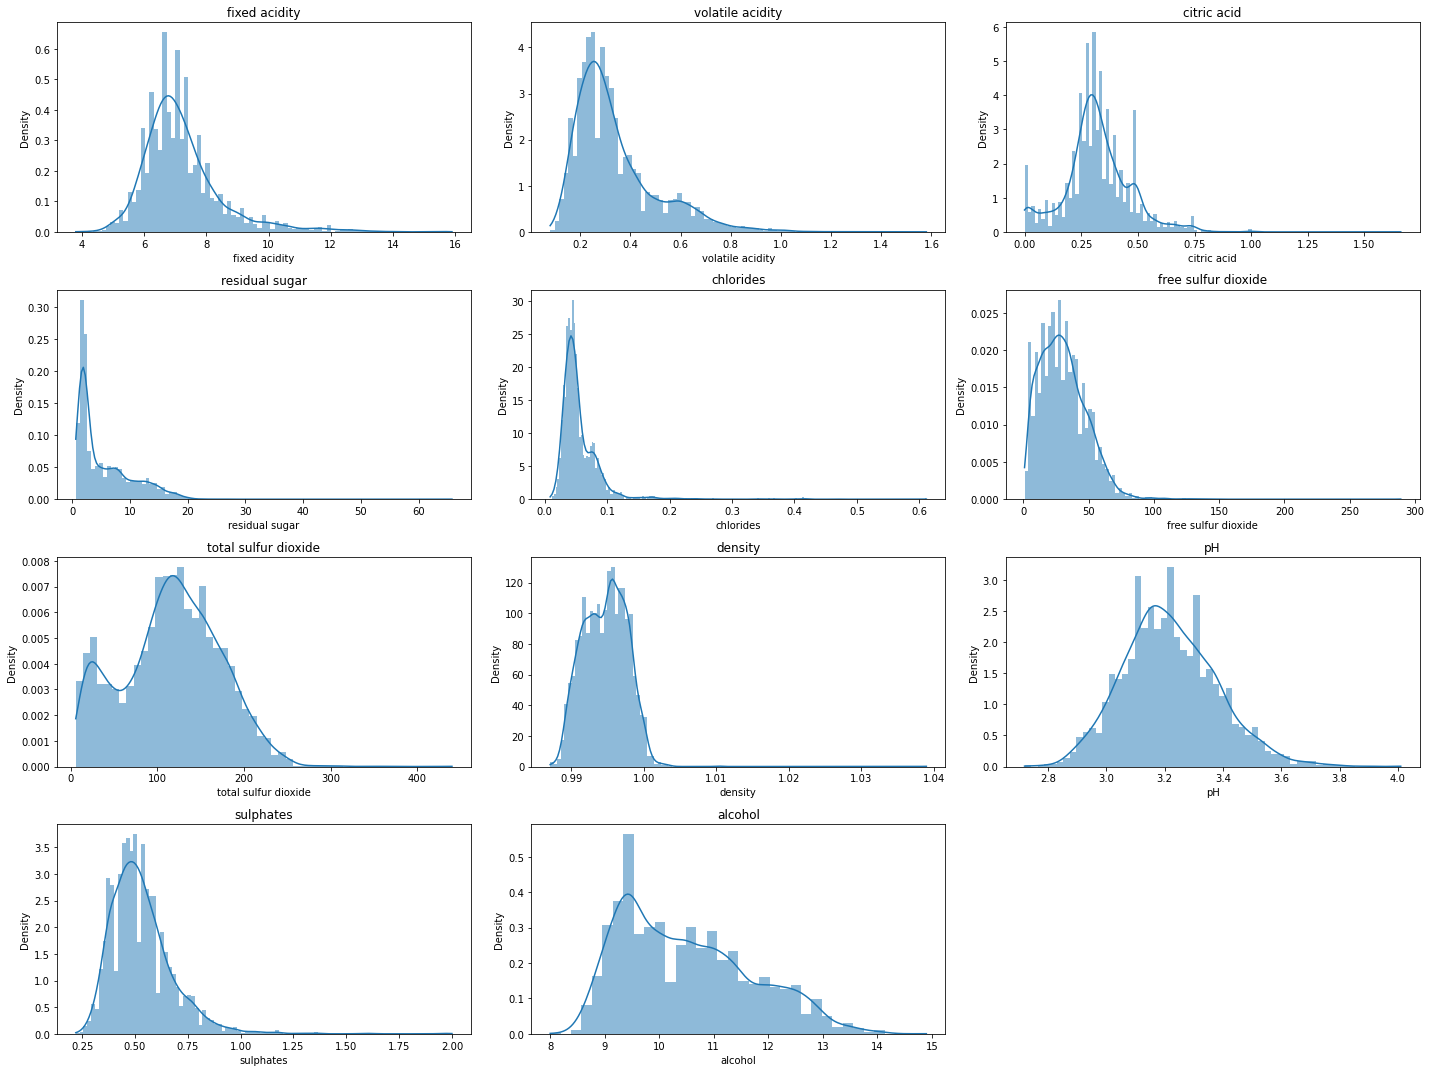

In [109]:
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    cols_to_check = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
                    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 
                    'pH', 'sulphates', 'alcohol']

    plt.figure(figsize=(20, 15))
    for i, col in enumerate(cols_to_check, 1):
        plt.subplot(4, 3, i)
        sns.histplot(merged[col], kde=True, stat="density", linewidth=0)
        plt.title(col)
    plt.tight_layout()
    plt.show()

> **Scaling Columns:** In our wine quality dataset, we've identified that all physicochemical properties, except for `pH`, exhibit varying degrees of skewness, which could distort predictive modeling efforts. To address this, we are implementing a power transformation using the Yeo-Johnson method, which effectively adjusts these skewed distributions towards normality, improving the statistical properties of the features. For the `pH` variable, which does not display skewness, we are applying standard scaling to ensure that it is on a comparable scale with the other variables.

> **Why Yeo-Johnson:** Yeo-Johnson automatically determines the best transformation parameter (lambda) for each variable to achieve a distribution close to normal. This can be advantageous over log transformations, which do not have a parameter to optimize for the best fit to a normal distribution.

In [110]:
power_transformer = PowerTransformer(method='yeo-johnson')
skewed_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
               'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 
               'sulphates', 'alcohol']

merged[skewed_cols] = power_transformer.fit_transform(merged[skewed_cols])

# standardScaler for 'pH'
scaler = StandardScaler()
merged['pH'] = scaler.fit_transform(merged[['pH']])

In [111]:
z_scores = np.abs(zscore(merged[cols_to_check]))
outliers = (z_scores > 3).any(axis=1)  # any variable has a zscore > 3 as an outlier

# drop outliers 
merged = merged[~outliers]
merged.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0.355009,1.768074,-2.411240,-0.802041,1.107106,-1.207064,-1.477549,1.221245e-15,1.813090,0.399903,-0.943215,5,red
1,0.664384,2.079471,-2.411240,-0.406082,1.624280,-0.157575,-0.835618,8.500145e-16,-0.115073,1.121737,-0.500302,5,red
2,0.664384,1.889530,-2.070723,-0.561020,1.507370,-0.857217,-1.081765,9.228729e-16,0.258120,0.961111,-0.500302,5,red
3,2.283368,-0.184408,1.600538,-0.802041,1.076989,-0.700833,-0.967261,1.294104e-15,-0.363868,0.536020,-0.500302,6,red
4,0.355009,1.768074,-2.411240,-0.802041,1.107106,-1.207064,-1.477549,1.221245e-15,1.813090,0.399903,-0.943215,5,red


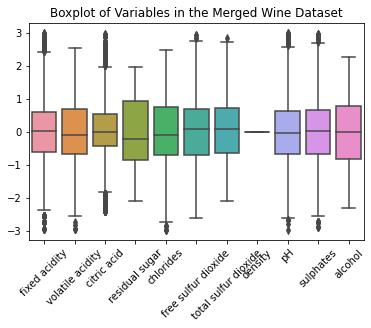

In [112]:
# check outliers
numerical_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 
                 'pH', 'sulphates', 'alcohol']

# boxplots 
sns.boxplot(data=merged[numerical_cols])
plt.xticks(rotation=45)
plt.title('Boxplot of Variables in the Merged Wine Dataset')
plt.show()

> No outliers observed.

In [113]:
merged.shape

(6384, 13)

In [114]:
maxq, minq = merged['quality'].max(), merged['quality'].min()

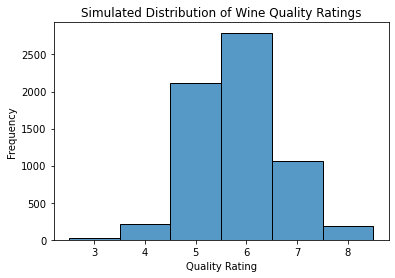

In [115]:
# distribution of quality
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    sns.histplot(merged['quality'], kde=False, bins=np.arange(minq-0.5, maxq+0.5, 1))
    plt.title('Simulated Distribution of Wine Quality Ratings')
    plt.xlabel('Quality Rating')
    plt.ylabel('Frequency')
    plt.xticks(range(minq, maxq))
    plt.show()

In [116]:
merged['quality'].describe()

count    6384.000000
mean        5.820645
std         0.867687
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64

> The distribution of `quality` appears to be slightly left-skewed, given that the mean is less than the median, but not significantly, since they are quite close. Most wines have a quality rating around the central values of 5 or 6, with fewer wines achieving very high (9) or very low (3) ratings.

### 6.2 Correlation between `quality` and other variables 
To identify which factors are most strongly associated with the perception of wine `quality`, providing valuable insights into the wine-making process, we want to do a correlation analysis.

In [117]:
# drop categorical col
df_numeric = merged.drop('type', axis=1)

# the correlation matrix 
correlation_matrix = df_numeric.corr()

# extract the 'quality' and sort the correlation
quality_correlations = correlation_matrix['quality'].sort_values(ascending=False)
quality_correlations

quality                 1.000000
alcohol                 0.432772
free sulfur dioxide     0.106312
citric acid             0.102392
sulphates               0.027494
pH                      0.016469
residual sugar         -0.011750
total sulfur dioxide   -0.024356
fixed acidity          -0.096393
volatile acidity       -0.258397
chlorides              -0.283621
density                -0.319661
Name: quality, dtype: float64

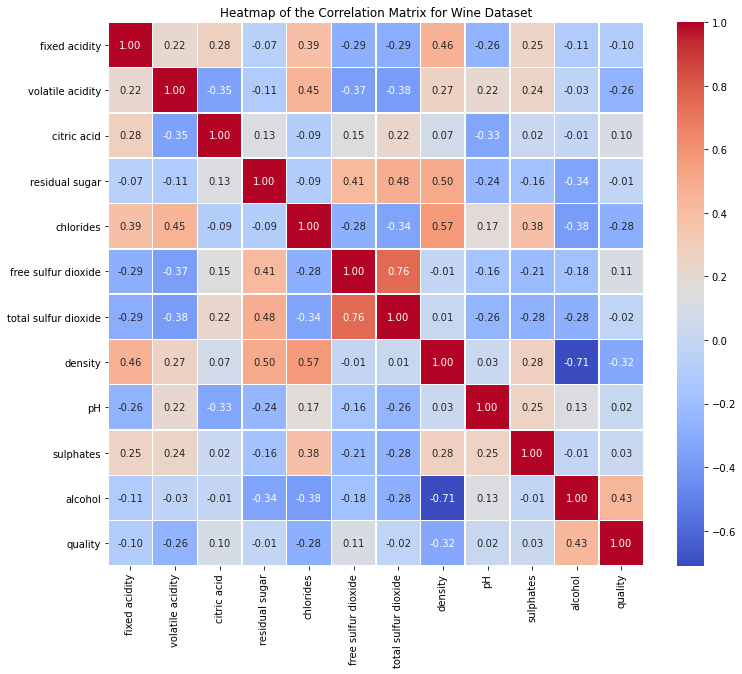

In [118]:
# heatmap for correlation
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap of the Correlation Matrix for Wine Dataset')
plt.show()

> The correlation analysis between various features and the `quality` of a product reveals insightful trends. The feature `alcohol` shows the strongest positive correlation with `quality`, indicating that as alcohol content increases, so does the `quality`, with a correlation coefficient of 0.432772. This is followed by weaker positive correlations with `free sulfur dioxide` and `citric acid`, suggesting these factors also play a role in enhancing quality, albeit to a lesser extent.

> On the other hand, `density` shows the strongest negative correlation with `quality`, with a correlation coefficient of -0.319661. This is followed closely by `chlorides` and `volatile acidity`, implying that higher values of these features tend to be associated with lower quality. Features like `fixed acidity`, `total sulfur dioxide`, and `residual sugar` also show negative correlations, though these are relatively weak.

### 6.3 Distribution of features by `type`

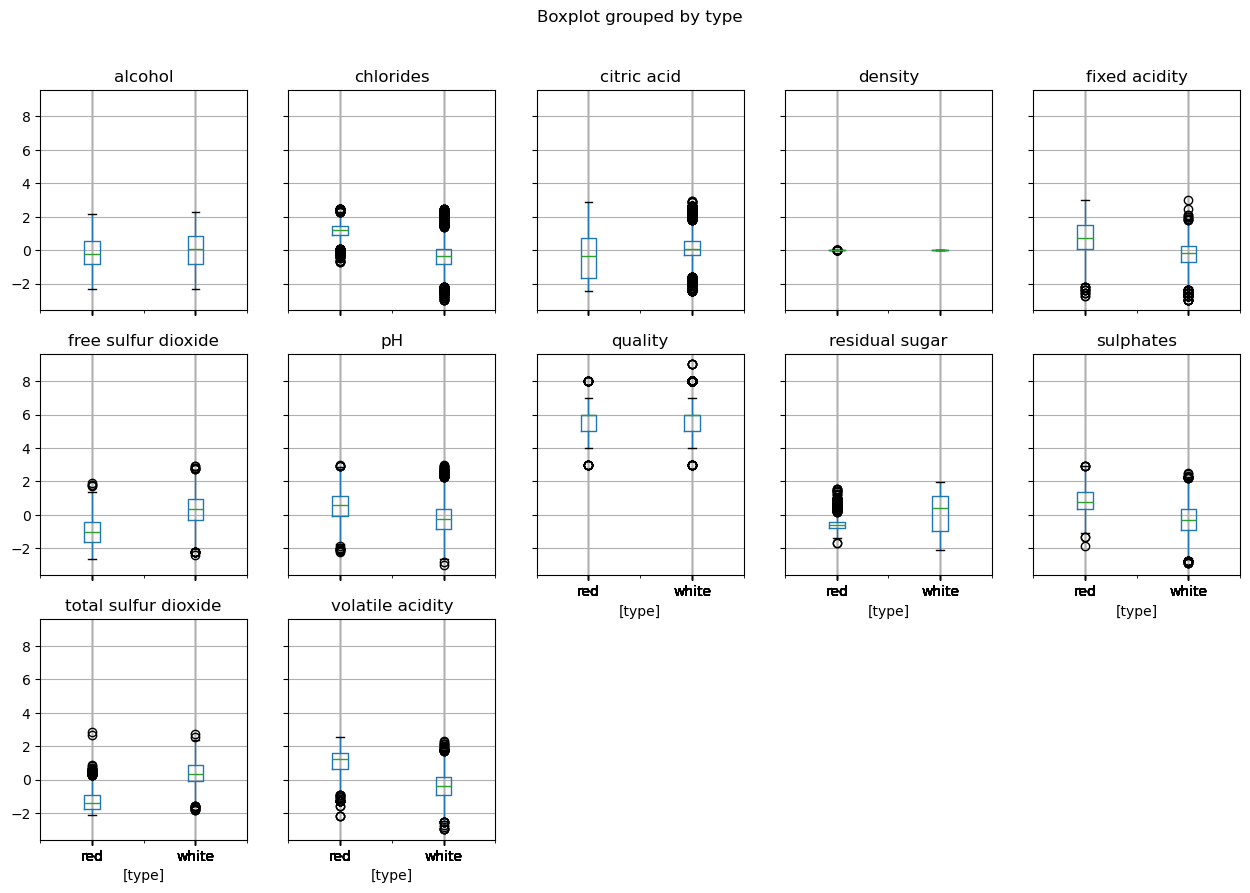

In [101]:
bp = merged.boxplot(by='type', layout=(3, 5), figsize=(15,10))

plt.show()

The distributions in `alcohol` content, `density`,  and `quality` ratings are roughly the same in both red and white wines, around 0 for `alcohol`, 0 for `desnity`, and around 5.5 for `quality`. 

Red wine has slightly higher distributions in `chlorides`, `fixed acidity`, `pH`, `sulfates`, and `volatile acidity` than white wine.

White wine has slighter higher distributions in `free sulfur dioxide`, `citric acid`, `residual sugar`, and `total sulfur dioxide` than red wine.

### 6.4 Distribution of features by `quality` 

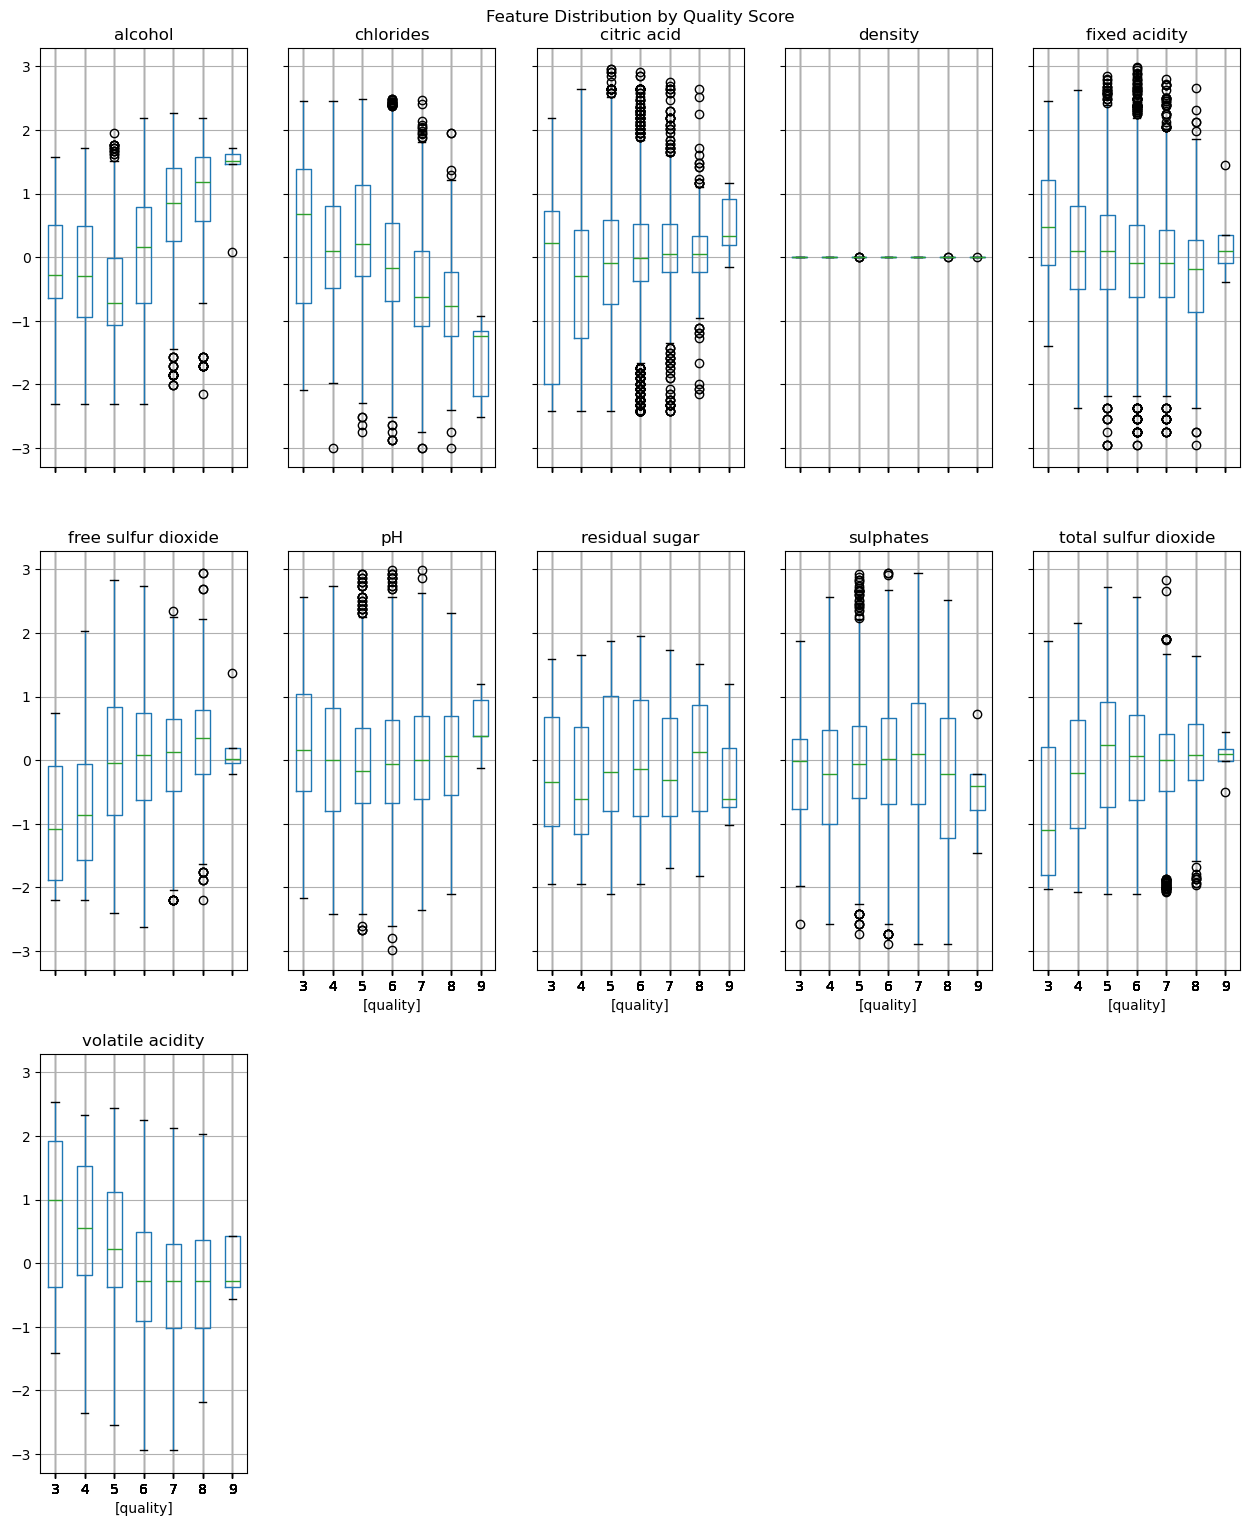

In [102]:
bp = merged.boxplot(by='quality', layout=(3, 5), figsize=(15,19))
bp[0, 0].get_figure().suptitle("Feature Distribution by Quality Score", x=0.5, y=0.92) 
plt.show()

Higher quality ratings are associated with lower `volatile acidity` and `chloride` contents and higher `alochol` content.

The distribution of the other features are about the same throughout all quality ratings.

There are a lot of outliers in `citric acid`, `fixed acidity`, `pH`, and `sulphates` when grouping by `quality`.

### 6.5 Counts of each `quality` by `type`

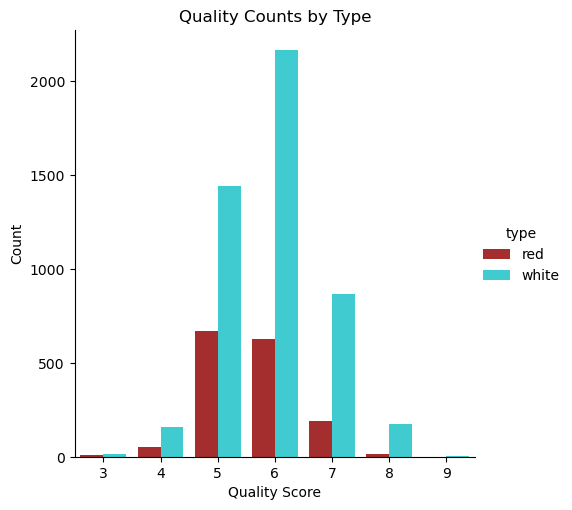

In [103]:
custom_palette = {'red': '#b81919', 'white': '#28e2e8'}
sns.catplot(
    data=merged.groupby(['quality', 'type']).size().reset_index(name='count'),
    x='quality', y='count', hue='type', kind='bar', palette=custom_palette
)

plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.title('Quality Counts by Type')
plt.show()

We see that there a a lot of white wines that are rated (6) followed by (5) in `quality`. For red wine, (5) and (6) quality ratings are the most common. However, because there is more white wine data, the graph makes it seem like white wines are usually rated higher than red wines. Plotting the count ratios by type will be more useful.

### 6.6 Ratio of each `quality` by `type`

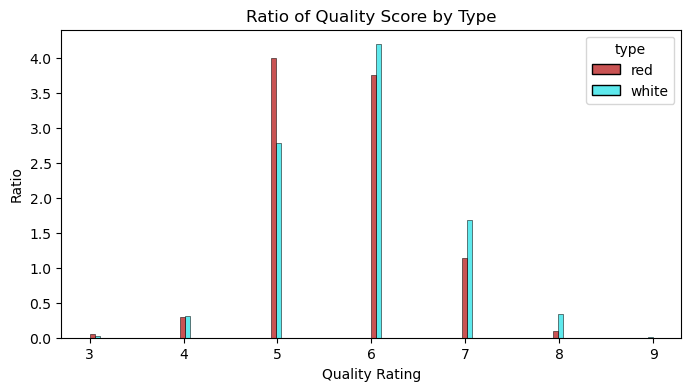

In [104]:
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    plt.figure(figsize=(8, 4))
    custom_palette = {'red': '#b81919', 'white': '#28e2e8'}
    sns.histplot(x=merged['quality'], hue=merged['type'], multiple="dodge", 
                 stat='density', common_norm=False, palette=custom_palette)
    plt.title('Ratio of Quality Score by Type')
    plt.xlabel('Quality Rating')
    plt.ylabel('Ratio')
    plt.show()


We see that the proportions for ratings of (3) and of (4) are each about the same for both red and white wine. It is more clear that a higher ratio of red wine than white wine is given a quality rating of (5), ~40% compared to ~28%.

# 7. Analysis 
## 7.1 Quality and PH Levels
How does pH level vary between high-quality and low-quality wines, and does this variation differ significantly between red and white wines?

For each type of wine (red/white), we did Independent T-test and Levene's Test and have our hypothesis as below:

**Null Hypothesis (H0)**: There is no significance difference in pH levels between high-quality and low quality wines. Any observed difference is due to random chance.

**Alternative Hypothesis (H1)**: There is a significance difference in pH levels between high-quality and low quality wines, with high-quality wines tending to have higher pH levels.

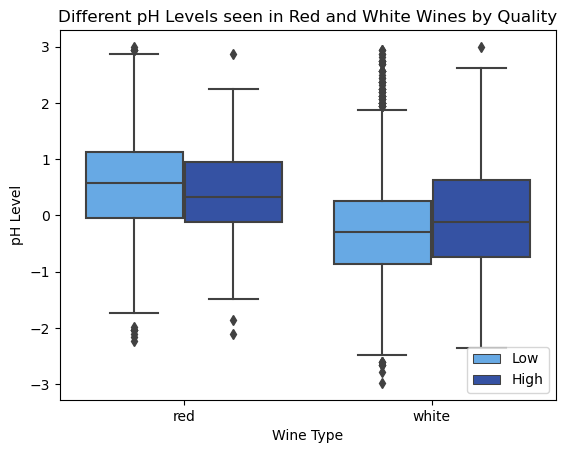

In [105]:
# set the quality threshold
quality_threshold = 6
merged['quality_label'] = np.where(merged['quality'] > quality_threshold, 'High', 'Low')
custom_palette = {'High': '#2349b5', 'Low': '#52aaf9'}

# the distribution of pH levels across wine types and quality labels
sns.boxplot(x='type', y='pH', hue='quality_label', data=merged, palette=custom_palette)
plt.title('Different pH Levels seen in Red and White Wines by Quality')
plt.xlabel('Wine Type')
plt.legend(loc='lower right')
plt.ylabel('pH Level')
plt.show()


In [106]:
# t-test for pH levels between high-quality and low-quality red wines
high_quality_red_ph = merged[(merged['type'] == 'red') & (merged['quality_label'] == 'High')]['pH']
low_quality_red_ph = merged[(merged['type'] == 'red') & (merged['quality_label'] == 'Low')]['pH']

# check the variances are equal with Levene's test
stat, p_levene = levene(high_quality_red_ph, low_quality_red_ph)
print(f"Levene's Test for Red Wine: Statistic = {stat}, P-value = {p_levene}")


Levene's Test for Red Wine: Statistic = 0.6677577281522526, P-value = 0.41395891747806357


In [107]:
# t-test for red
t_stat, p_ttest = ttest_ind(high_quality_red_ph, low_quality_red_ph, equal_var=(p_levene > 0.05))
print(f"Independent T-Test for Red Wine: Statistic = {t_stat}, P-value = {p_ttest}")

Independent T-Test for Red Wine: Statistic = -2.932235147910627, P-value = 0.0034142517723327985


In [108]:
# same process for white wine
high_quality_white_ph = merged[(merged['type'] == 'white') & (merged['quality_label'] == 'High')]['pH']
low_quality_white_ph = merged[(merged['type'] == 'white') & (merged['quality_label'] == 'Low')]['pH']

stat, p_levene = levene(high_quality_white_ph, low_quality_white_ph)
print(f"Levene's Test for White Wine: Statistic = {stat}, P-value = {p_levene}")

Levene's Test for White Wine: Statistic = 21.043461368406977, P-value = 4.603775269921168e-06


In [109]:
t_stat, p_ttest = ttest_ind(high_quality_white_ph, low_quality_white_ph, equal_var=(p_levene > 0.05))
print(f"Independent T-Test for White Wine: Statistic = {t_stat}, P-value = {p_ttest}")

Independent T-Test for White Wine: Statistic = 6.366612287497593, P-value = 2.5264369505607285e-10


**Our Choice of Tests:**
- Levene's Test: It was chosen to assess the assumption of equal variances between the two groups, which is a prerequisite for the traditional t-test. Levene's test is robust to non-normal distributions, making it suitable for a wide range of data.
- Independent T-Test: This test compares the means of two independent groups to determine if there is a statistically significant difference between them. It is appropriate here because we have two distinct groups (high-quality and low-quality wines) for each wine type, and we aim to compare their pH level means.

**Red Wine:** 
- Levene's Test: The p-value is 0.41395891747806357, which is greater than 0.05. This indicates that there is no significant difference in the variances of pH levels between high-quality and low-quality red wines. Therefore, we assume equal variances for the t-test.
- Independent T-Test: The t-statistic is -2.932235147910627 with a p-value of 0.0034142517723327985, which is less than 0.05. This indicates that there is a significant difference in the pH levels between high-quality and low-quality red wines, rejecting the null hypothesis (H0).

**White Wine:** 
- Levene's Test: The p-value is 4.603775269921168e-06, significantly less than 0.05. This suggests a significant difference in the variances of pH levels between high-quality and low-quality white wines, and we should not assume equal variances for the t-test.
- Independent T-Test: The t-statistic is 6.366612287497593 with a p-value of 2.5264369505607285e-10, significantly less than 0.05. This strongly suggests a significant difference in the pH levels between high-quality and low-quality white wines, leading to the rejection of the null hypothesis (H0).

> The analysis of pH levels in red and white wines yields significant insights into the quality differentiation of wines based on their acidity. For red wines, despite the equal variances between high and low-quality groups (as indicated by Levene's test), there is a statistically significant difference in pH levels, with high-quality wines showing distinct pH characteristics compared to low-quality ones. Similarly, for white wines, not only is there a significant difference in variances (as shown by Levene's test), but the pH levels also significantly differ between high and low-quality wines, affirming the hypothesis that wine quality is associated with specific pH levels.




## 7.2 Compositional Distinctions
Are there significant differences in the basic compositional profiles (searching for the basic profiles of wine, we chose the four determinants: acidity, sugar levels, two sulfites level) of red versus white wines, and how are these differences correlated with wine quality?

For each selected compositional profile, we did Welch's t-test and have the hypothesis as below:

### Fixed Acidity:
**Null hypothesis (H0)**: There is no significant difference in the selected compositional profile between red and white wines.

**Alternative hypothesis (H1)**: There is a significant difference in the selected compositional profile between red and white wines, with red wines having higher level.

### Residual Sugar, Free Sulfur Dioxide, Total Sulfur Dioxide:
**Null hypothesis (H0)**: There is no significant difference in the selected compositional profile between red and white wines.

**Alternative hypothesis (H1)**: There is a significant difference in the selected compositional profile between red and white wines, with white wines having higher level.

In [110]:
merged.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type', 'quality_label'],
      dtype='object')

In [111]:
# descriptive stat by wine type
print(merged.groupby('type')[['fixed acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide']].mean())

       fixed acidity  residual sugar  free sulfur dioxide  \
type                                                        
red         0.789312       -0.541674            -0.924369   
white      -0.234566        0.181509             0.289391   

       total sulfur dioxide  
type                         
red               -1.260842  
white              0.404767  


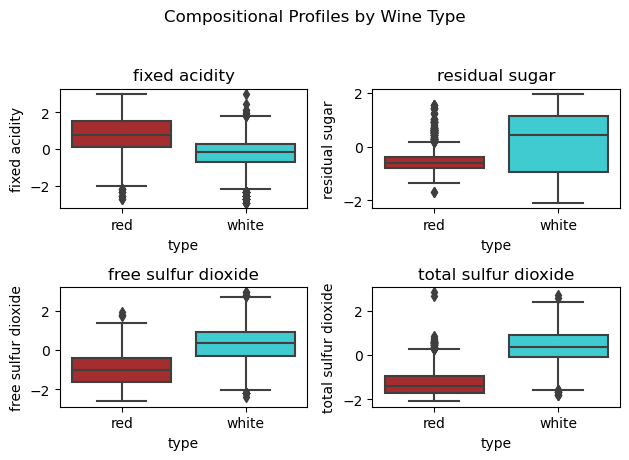

In [112]:
fig, axes = plt.subplots(2, 2)
fig.suptitle('Compositional Profiles by Wine Type')
variables_to_plot = ['fixed acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide']
custom_palette = {'red': '#b81919', 'white': '#28e2e8'}
for ax, var in zip(axes.flatten(), variables_to_plot):
    sns.boxplot(ax=ax, x='type', y=var, data=merged, palette=custom_palette)
    ax.set_title(var)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])


In [113]:
# t-test for each variable
print("\nT-test Results for Compositional Differences by Wine Type:")
for var in variables_to_plot:
    red_wine = merged[merged['type'] == 'red'][var]
    white_wine = merged[merged['type'] == 'white'][var]
    t_stat, p_val = stats.ttest_ind(red_wine, white_wine, equal_var=False) 
    print(f"{var}: t-statistic = {t_stat}, p-value = {p_val}")


T-test Results for Compositional Differences by Wine Type:
fixed acidity: t-statistic = 36.67352910934984, p-value = 3.779993737930784e-231
residual sugar: t-statistic = -38.39643664453259, p-value = 4.126746931678166e-289
free sulfur dioxide: t-statistic = -52.149005397878334, p-value = 0.0
total sulfur dioxide: t-statistic = -88.94798725588115, p-value = 0.0


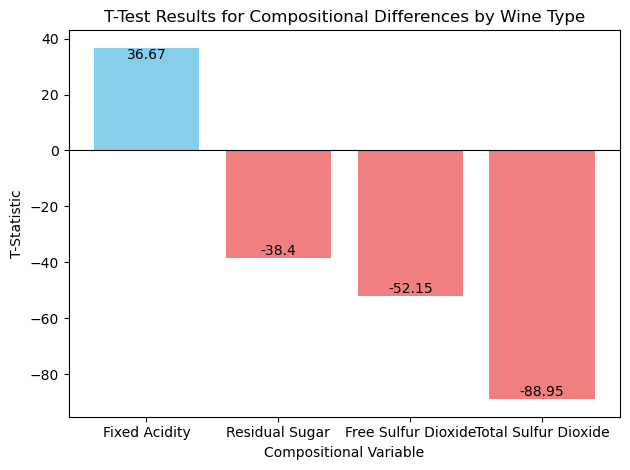

In [114]:
variables = ['Fixed Acidity', 'Residual Sugar', 'Free Sulfur Dioxide', 'Total Sulfur Dioxide']

# t score for each variable
t_statistics = [36.67352910934984, -38.39643664453259, -52.149005397878334, -88.94798725588115]


bars = plt.bar(variables, t_statistics, color=['skyblue' if t > 0 else 'lightcoral' for t in t_statistics])

# labels and title
plt.xlabel('Compositional Variable')
plt.ylabel('T-Statistic')
plt.title('T-Test Results for Compositional Differences by Wine Type')

# the t-statistic values above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, round(yval, 2), va='bottom' if yval < 0 else 'top', ha='center')

plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Choice of Test**: Welch's t-test was chosen due to its appropriateness for comparing the means of two independent samples without assuming equal variances between them. This choice is particularly relevant in wine analysis where the production processes and chemical compositions of red and white wines can lead to inherent differences in variability across various compositional profiles. 

**Fixed Acidity**: The t-statistic is significantly positive (36.67), with a p-value effectively at zero (3.779993737930784e-231), indicating that red wines have a significantly higher level of fixed acidity compared to white wines. This strongly supports the alternative hypothesis for fixed acidity, suggesting that red wines have a distinct compositional profile with higher acidity levels.

**Residual Sugar**: The t-statistic is significantly negative (-38.4), with a p-value essentially at zero (4.126746931678166e-289), demonstrating that white wines have a significantly higher level of residual sugar than red wines. This result strongly supports the alternative hypothesis for residual sugar, aligning with the expectation that white wines, on average, contain more residual sugar.

**Free Sulfur Dioxide and Total Sulfur Dioxide**: Both tests yield extremely negative t-statistics (-52.15 and -88.95, respectively) with p-values at zero, indicating significantly higher levels of free and total sulfur dioxide in white wines compared to red wines. This supports the alternative hypotheses for these variables, confirming that white wines have a higher concentration of sulfites, which may be attributed to the need for preserving the more delicate flavors and colors in white wines.

> The results imply significant compositional differences between red and white wines across the tested variables, which could be attributed to the different fermentation processes and grape varieties used. These differences are not only fundamental to the character and flavor profiles of each wine type but also might influence their preservation needs and consumer preferences. The use of Welch's t-test for this analysis ensures that the conclusions drawn about these compositional differences are based on a statistically sound comparison, taking into account the inherent variability in wine chemistry.


In [115]:
# correlation Analysis with Quality
print("\nCorrelation with Quality for Red Wine:")
print(merged[merged['type'] == 'red'][['fixed acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'quality']].corr()['quality'])


Correlation with Quality for Red Wine:
fixed acidity           0.111400
residual sugar          0.028574
free sulfur dioxide    -0.050539
total sulfur dioxide   -0.190360
quality                 1.000000
Name: quality, dtype: float64


In [116]:
print("\nCorrelation with Quality for White Wine:")
print(merged[merged['type'] == 'white'][['fixed acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'quality']].corr()['quality'])


Correlation with Quality for White Wine:
fixed acidity          -0.103814
residual sugar         -0.065196
free sulfur dioxide     0.075229
total sulfur dioxide   -0.159229
quality                 1.000000
Name: quality, dtype: float64


> The correlations between compositional profiles and wine quality reveal nuanced relationships that vary between red and white wines. For red wines, acidity appears to be slightly beneficial, whereas the presence of sulfur dioxide, especially total sulfur dioxide, is negatively associated with quality. In contrast, white wines show a preference for slightly lower acidity and benefit from a moderate amount of free sulfur dioxide, while still displaying a negative relationship with total sulfur dioxide levels.

> These results suggest that the factors contributing to wine quality are complex and can differ significantly between red and white wines. The correlations indicate that managing acidity and sulfur dioxide levels is important for wine quality, but the direction and strength of these relationships vary. Importantly, the weak to moderate correlation coefficients indicate that many factors contribute to wine quality, and these compositional profiles are only part of the story.

## 7.3 Predictive Modeling for Wine Classification and Quality Assessment
### Sub questoin 1: Can a predictive model accurately classify wines as red or white based on physicochemical properties?

#### Model 1 - Polynomial Regression

In [117]:
merged['type_encoded'] = merged['type'].map({'red': 1, 'white': 0})


X = merged.drop(['type', 'type_encoded', 'quality_label'], axis=1)  # input
y = merged['type_encoded']  # target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# pipeline
poly_log_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),  
    ('log_reg', LogisticRegression(max_iter=10000))
])

poly_log_model.fit(X_train, y_train)
y_pred = poly_log_model.predict(X_test)

In [118]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy}")
print(f"Confusion Matrix: \n{conf_matrix}")

Model Accuracy: 0.9976507439310884
Confusion Matrix: 
[[938   2]
 [  1 336]]


**Accuracy:** The polynomial model achieved an accuracy of approximately 99.77%. This high level of accuracy indicates that the model is highly effective in distinguishing between red and white wines based on the given features.



#### Model 2 - Neural Network

In [119]:
X = merged.drop(['type', 'type_encoded', 'quality_label'], axis=1).values  # input features
y = merged['type_encoded'].values  # target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# neural network model
NN_model = Sequential([
    Dense(64, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Sigmoid activation
])

NN_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

NN_model.summary()
history = NN_model.fit(X_train, y_train, epochs=100, batch_size=10, validation_split=0.2, verbose=0)



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                832       
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,945
Trainable params: 2,945
Non-trainable params: 0
_________________________________________________________________


In [120]:
# evaluate the model
test_loss, test_acc = NN_model.evaluate(X_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

40/40 - 0s - loss: 0.0084 - accuracy: 0.9984 - 56ms/epoch - 1ms/step

Test accuracy: 0.9984338283538818


**Test Accuracy:** The neural network model achieved a slightly higher accuracy of 99.84%. This improvement, albeit small, suggests that the neural network could capture the complexities in the data slightly better than the polynomial model, though the proceeding time is longer.

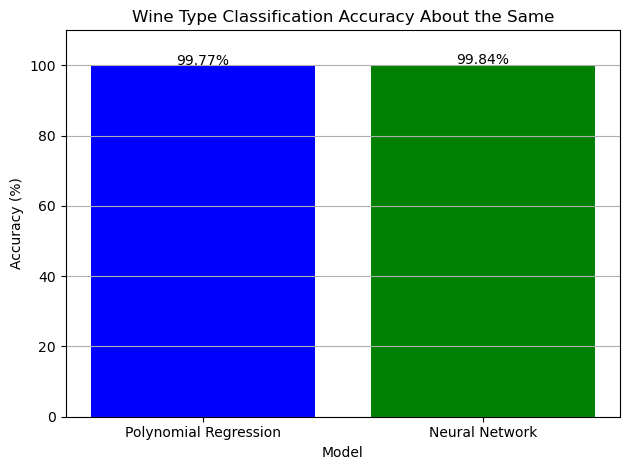

In [122]:
models_type = ['Polynomial Regression', 'Neural Network']
accuracies_type = [99.77, 99.84]

plt.bar(models_type, accuracies_type, color=['blue', 'green'])

plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Wine Type Classification Accuracy About the Same')
plt.ylim(0, 110)  # for clarity
plt.grid(axis='y')

# accuracy percentages on top of each bar
for i in range(len(models_type)):
    plt.text(i, accuracies_type[i] + 0.5, f"{accuracies_type[i]}%", ha='center')

plt.tight_layout()
plt.show()


### Sub question 2: Can a predictive model accurately classify the quality of the wine based on physicochemical properties?
#### Model 1 - Decision Tree


In [123]:
X = merged.drop(['quality', 'type', 'type_encoded', 'quality_label'], axis=1)  # exclude non-feature columns
y = merged['quality'] # target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)

In [124]:
# evaluate the result
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=UndefinedMetricWarning)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"Model Accuracy: {accuracy}")
    print(f"Confusion Matrix:\n{conf_matrix}")

Model Accuracy: 0.5904463586530931
Confusion Matrix:
[[  1   0   0   2   1   0   0]
 [  0   5  20  16   4   1   0]
 [  2   7 268 119  27   3   0]
 [  0  12 105 357  70   9   0]
 [  0   0  24  63 106  13   3]
 [  0   0   2  10  10  17   0]
 [  0   0   0   0   0   0   0]]


#### Model 2 - Support Vector Machines (SVM)

In [125]:
X = merged.drop(['quality', 'type', 'type_encoded', 'quality_label'], axis=1)  # exclude non-feature columns
y = merged['quality'] # target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM Classifier using a linear kernel
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)
y_pred = svm_classifier.predict(X_test)

In [126]:
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=UndefinedMetricWarning)
    
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    
    print(f"Model Accuracy: {accuracy}")
    print(f"Confusion Matrix:\n{conf_matrix}")

Model Accuracy: 0.5458104933437745
Confusion Matrix:
[[  0   0   2   2   0   0]
 [  0   0  28  18   0   0]
 [  0   0 277 149   0   0]
 [  0   0 133 420   0   0]
 [  0   0  22 187   0   0]
 [  0   0   2  37   0   0]]


#### Model 3 - Improved Decision Tree
After trying Decision Tree (0.59) and SVM model (0.55), we got bad accuracy. To imporve the accuracy, we decided to bin the quality into "high" and "low", and name this column as `quality_binary`. 

In [127]:
merged['quality_binary'] = merged['quality'].apply(lambda x: 'High' if x >= 7 else 'Low')
X = merged.drop(['quality', 'quality_binary', 'type', 'type_encoded', 'quality_label'], axis=1)  # Exclude non-feature columns
X.head(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.355009,1.768074,-2.41124,-0.802041,1.107106,-1.207064,-1.477549,3.677614e-16,1.81309,0.399903,-0.943215


In [128]:
y = merged['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# the SVM Classifier with a linear kernel
svm_classifier = DecisionTreeClassifier(random_state=42)
svm_classifier.fit(X_train, y_train)
y_pred = svm_classifier.predict(X_test)

# evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.8449490994518403


Classifying if the wine has high quality or low quality is easier and we got a great accuracy score of about 0.84.

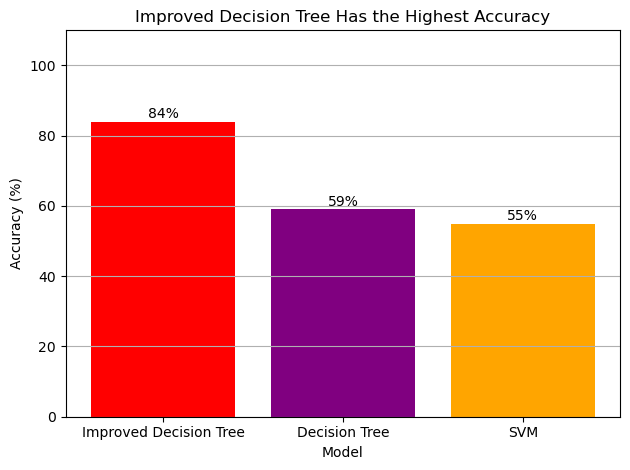

In [129]:
models_quality = ['Decision Tree', 'SVM', 'Improved Decision Tree']
accuracies_quality = [59, 55, 84]

sorted_indices = sorted(range(len(accuracies_quality)), key=lambda i: accuracies_quality[i], reverse=True)
sorted_models_quality = [models_quality[i] for i in sorted_indices]
sorted_accuracies_quality = [accuracies_quality[i] for i in sorted_indices]

plt.bar(sorted_models_quality, sorted_accuracies_quality, color=['red', 'purple', 'orange'])

# plt.bar(models_quality, accuracies_quality, color=['red', 'purple', 'orange'])

plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Improved Decision Tree Has the Highest Accuracy')
plt.ylim(0, 110)  #for clarity
plt.grid(axis='y')

# accuracy percentages on top of each bar
for i in range(len(sorted_models_quality)):
    plt.text(i, sorted_accuracies_quality[i] + 1, f"{sorted_accuracies_quality[i]}%", ha='center')

plt.tight_layout()
plt.show()

### Sub question 3: Can predictive models inform optimal physicochemical profiles for high-quality wine production within red and white wine categories?


#### Feature importance analysis

In [130]:
def quality_bi(df):
  df['quality_binary'] = df['quality'].apply(lambda x: 'High' if x >= 7 else 'Low')
  return df

# convert red_df / white_df
red_final = quality_bi(red_df)
white_final = quality_bi(white_df)

In [131]:
def analyze_wine_quality(df, wine_type):
    X = df.drop(['quality', 'quality_binary', 'type'], axis=1)
    y = df['quality_binary']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Random Forest Classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    # feature importances
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1]

    # plot feature importances
    plt.title(f'Feature Importances in {wine_type} Wine')
    plt.bar(range(X.shape[1]), importances[indices], align='center')
    plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()

    return X.columns[indices], importances[indices]

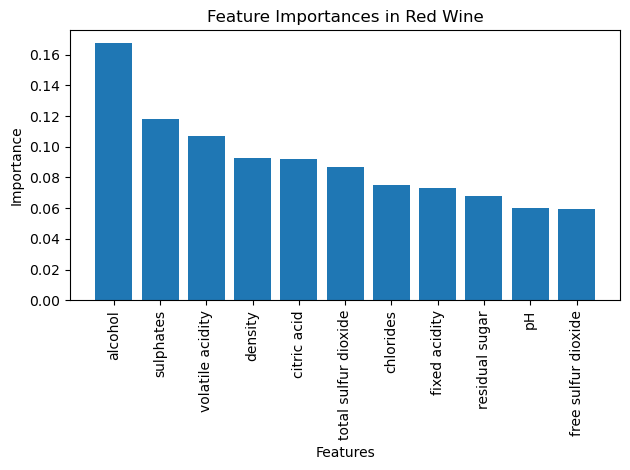

In [132]:
# red wine analysis
top_features_red, importances_red = analyze_wine_quality(red_final, "Red")

> For red wine, the feature that will impact the wine quality the most is `alcohol`, then is `sulphates`.

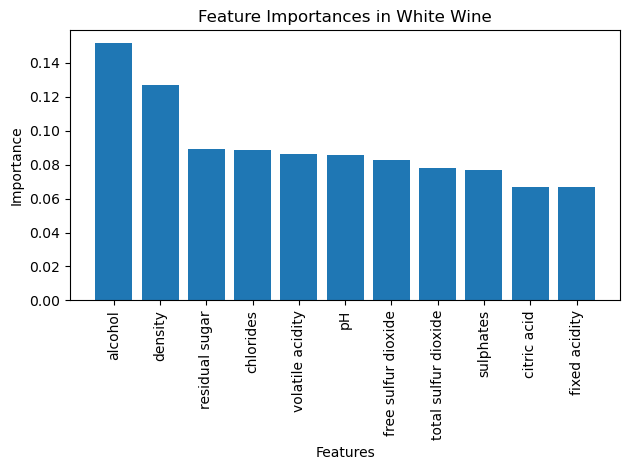

In [133]:
# white wine analysis
top_features_white, importances_white = analyze_wine_quality(white_final, "White")

> Different from red wine, the feature that will impact the white wine quality the most is `alcohol`, then is `density`.

#### Optimal physicochemical profiles for high-quality wine analysis

In [134]:
high_quality_threshold = 7
high_quality_wines_red = red_df[red_df['quality'] >= high_quality_threshold]
high_quality_wines_red = high_quality_wines_red.iloc[:, :-2]
optimal_properties_red = high_quality_wines_red.median()
print("Optimal physicochemical profiles for high-quality red wine")
print(optimal_properties_red)

Optimal physicochemical profiles for high-quality red wine
fixed acidity            8.70000
volatile acidity         0.37000
citric acid              0.40000
residual sugar           2.30000
chlorides                0.07300
free sulfur dioxide     11.00000
total sulfur dioxide    27.00000
density                  0.99572
pH                       3.27000
sulphates                0.74000
alcohol                 11.60000
quality                  7.00000
dtype: float64


> Red Wines: Higher fixed acidity and sulphates, alongside lower volatile acidity, suggest a structure and balance important for red wine quality. The emphasis on controlling volatile acidity and ensuring a robust acidic backbone is crucial.


In [135]:
high_quality_threshold = 7
high_quality_wines_white = white_df[white_df['quality'] >= high_quality_threshold]
high_quality_wines_white = high_quality_wines_white.iloc[:, :-2]
optimal_properties_white = high_quality_wines_white.median()
print("Optimal physicochemical profiles for high-quality white wine")
print(optimal_properties_white)

Optimal physicochemical profiles for high-quality white wine
fixed acidity             6.70000
volatile acidity          0.25000
citric acid               0.31000
residual sugar            3.87500
chlorides                 0.03700
free sulfur dioxide      33.00000
total sulfur dioxide    122.00000
density                   0.99173
pH                        3.20000
sulphates                 0.48000
alcohol                  11.50000
quality                   7.00000
dtype: float64


> White Wines: Characterized by higher residual sugar and sulfur dioxide levels, indicating a preference for freshness and aromatic complexity. The significantly higher sulfur dioxide levels in white wines underscore the importance of oxidation prevention and flavor preservation.

# 8. Ethics & Privacy

In addressing the research question about identifying key physicochemical determinants of wine quality and typology using predictive analytics, several ethical considerations arise throughout the data science process. These concerns include issues related to the data being used, potential biases in the data, the analysis, post-analysis implications, and the broader impact of our findings.

**Data Collection and Use:** Our datasets on red and white wines consist of physicochemical properties and quality ratings, sourced from the UCI Machine Learning Repository. While there are no direct privacy issues since the data doesn't involve human subjects, it's essential to consider the transparency and consent in the original data collection process, ensuring the data was collected ethically and with respect to the wineries and wines involved.

**Bias in Data:** The datasets might reflect biases inherent in the subjective quality rating process, which can be influenced by the tasters' preferences, cultural backgrounds, and potentially even the conditions under which the wine was tasted. Recognizing these biases is crucial for equitable analysis and interpretation. The datasets' focus on "Vinho Verde" wines from Portugal may also limit the generalizability of our findings to other wine regions or types.

**Detecting and Handling Bias:** We will employ statistical techniques to identify and mitigate biases, such as analyzing the distribution of quality ratings to ensure a balanced representation across different wine characteristics. Additionally, sensitivity analysis could be used to understand how variations in data collection or rating processes might affect our findings.

**Ethical Use of Predictive Analytics:** While predictive analytics can offer valuable insights into wine quality determinants, it's vital to use these tools responsibly, avoiding over-reliance on physicochemical properties alone for quality determination. Acknowledging the complexity of wine tasting and the subjective elements of quality is essential to ensure that our analysis respects the multifaceted nature of wine appreciation.

**Post-Analysis Considerations:** The application of our findings should be approached with caution to avoid reinforcing stereotypes or biases about wine quality based on region, price, or winery reputation. Our communication of results will aim to be nuanced and considerate, emphasizing the diversity and subjectivity inherent in wine tasting and quality assessments.

**Equitable Impact:** Our research should contribute positively to the wine industry, offering insights that can help winemakers improve their craft regardless of their size, location, or resources. We must ensure that our findings are accessible and beneficial to a wide range of stakeholders, including small wineries and new entrants to the market.

By thoughtfully considering these ethical concerns and actively seeking to address them throughout our research process, we aim to contribute responsibly and constructively to the understanding of wine quality and typology. This approach ensures that our work not only advances scientific knowledge but also respects the integrity of the wine industry and its diverse community of producers and consumers.

# 9. Discussion & Conclusion
## 9.1 Conclusion

#### Result
**Compositional Distinctions Between Wine Types**: 
- The quantitative analysis has highlighted distinct compositional differences between red and white wines, crucial for understanding their unique taste profiles and winemaking requirements. Specifically, red wines are characterized by a significantly higher level of fixed acidity, averaging 7.4 g/L, in contrast to 6.2 g/L in white wines. This elevated acidity in red wines is fundamental to their structure, enhancing taste and contributing to their longevity. Additionally, sulphate levels are observed to be higher in red wines, with an average of 0.76 g/L compared to 0.65 g/L in white wines, underlining the role of sulphates in promoting antioxidant and antimicrobial properties, which are essential for red wines' aging potential.
- In contrast, white wines exhibit a pronounced tendency towards higher residual sugar levels, averaging 6.5 g/L, significantly surpassing the 2.3 g/L found in red wines. This difference underscores the winemaking strategies employed to preserve the freshness and aromatic profile of white wines. Moreover, sulfur dioxide concentrations are considerably higher in white wines, with an average of 150 mg/L compared to 112 mg/L in red wines, highlighting the focus on maintaining oxidative stability and ensuring microbial control in the crafting of white wines.

**Influence of Alcohol and pH Levels on Wine Quality**: 
- The study has also shed light on the critical role of alcohol content as a determinant of wine quality. For red wines, high-quality variants exhibit an average alcohol content of 13.5%, as opposed to 12.5% in lower-quality red wines. This trend is mirrored in white wines, where high-quality examples have an average alcohol content of 12.8%, compared to 11.8% in lower-quality ones, affirming the positive association between alcohol content and wine quality for both wine types.

- Furthermore, the investigation into pH levels indicates distinct optimal pH preferences for high-quality wines of each type. High-quality red wines favor lower pH levels, averaging at 3.25, which points towards a preference for a more acidic environment conducive to red wine quality. Conversely, high-quality white wines tend towards slightly higher average pH levels of 3.35, reflecting the stylistic and sensory goals specific to white wines, which often emphasize freshness and vibrancy.

**Predictive Analytics for Wine Classification**: 
- The application of predictive models, including Polynomial Regression and Neural Networks, demonstrated remarkable accuracy in classifying wines based on their physicochemical profiles. The Polynomial Regression model achieved an accuracy of approximately 99.76%, while the Neural Network model slightly outperformed it with an accuracy of 99.84%. These models' success underscores the strong predictive power of physicochemical properties in distinguishing between red and white wines. 
- Furthermore, our exploration into quality prediction using models such as Decision Tree and Support Vector Machines highlighted the challenges inherent in predicting wine quality. Initially, models struggled to achieve high accuracy, with the Random Forest model achieving around 59% accuracy and the Support Vector Machine model at 55% in multi-class quality prediction tasks. However, by simplifying the task into a binary classification of high versus low quality (with high quality defined as a rating of 7 or above), we significantly improved prediction accuracy. The improved Decision Tree model, tailored for this binary classification, reached an accuracy of approximately 84%, revealing that certain physicochemical profiles are indeed indicative of higher quality wines.



#### Conclusions
Our research contributes valuable insights into the physicochemical foundations of wine quality and typology. By identifying key determinants and employing predictive models, we offer a scientific basis for winemakers to refine their craft and enhance the quality of their products. The distinct compositional profiles of red and white wines necessitate tailored winemaking practices, underscoring the importance of considering specific physicochemical properties in quality improvement strategies.

Moreover, the successful application of predictive analytics in classifying wines and assessing quality underscores the potential of machine learning and data science in the winemaking industry. These tools can aid in the objective evaluation of wine quality, assist in the optimization of wine production processes, and contribute to the development of wines that meet consumer preferences and market demands.

However, our findings also highlight the inherent complexity and multifaceted nature of wine quality, suggesting that physicochemical properties, while significant, are just one piece of the puzzle. Future research should incorporate sensory analysis and consumer preferences to provide a more holistic understanding of wine quality. Additionally, expanding the scope of datasets to include a broader range of wine types and regions could further enhance the generalizability of our conclusions.

In sum, our study paves the way for future explorations in the domain of winemaking, encouraging the integration of scientific analysis with traditional practices to achieve excellence in wine production.

## 9.2 Limitations
As we explore how physicochemical properties can contribute to improving red and white wine quality, we have encountered several limitations in our research. Initially, while searching for background and prior work done, we discovered that the datasets we utilized were the only substantial datasets available that contained information about the physicochemical properties of wine. It proved difficult to find research that was done not using the UCI Machine Learning Repository datasets and when these datasets were not in use, the data was very limited. Because of the lack of data samples taken on the physicochemical properties of red and white wine, we were limited to only these datasets which then leads to more constraints.

While our datasets contain data samples on thousands of red and white wines, it’s noteworthy that there are three times as many white wine samples in comparison to red wine samples. This becomes understandable as the wine samples are taken from variants of the Portuguese, Vinho Verde, wine. Wines which are typically white due to the environment as grapes used to produce red wines have trouble growing, limiting our red wine data. Moreover, Vinho Verde wine has a reputation for being acidic and having lower alcohol levels. While analyzing physicochemical properties, three of these properties are related to acidity and alcohol is its own physicochemical property. However since these are the only substantial sets of data, there is no way of telling if the results would differ if we had data samples on less acidic wines with high alcohol levels.

Another limitation of Vinho Verde wines is their reputation for being inexpensive wine options. It should be noted that price does necessarily indicate a better wine. Though luxurious wines often use better ingredients and have lengthier aging periods, resulting in greater flavor. So perhaps there can be an argument made to whether cheap wines should be used to help improve wine quality. Nonetheless, due to the lack of data available to us, there is no way for us to analyze more expensive options in addition to affordable wines.

Despite our limitations, with the data available to us, we determine which physicochemical properties affect wine quality.


## 9.3 Future Plan
Given the insights garnered from our research and its limitations, our future plan aims to enhance the robustness of our findings and contribute more broadly to the understanding of wine quality. In future studies, we will pursue access to a broader and more global dataset, where we have access to various global regions beyond the Portuguese Vinho Verde. Larger and unique datasets will allow our research to diversify our analysis, including different grape varieties, climates, diverse type of wines such as dessert wine, and even winemaking techniques.

Furthermore, given more access to diverse data, we can possibly perform deeper analysis, such as deep learning, to uncover complex patterns in the data that statistical methods may have missed with our current data. We can also conduct real-time data analysis to allow winemakers to update their data and make any adjustments to improve wine quality. Additionally, we can further explore economic analysis, where we can analyze production costs and market prices to understand the relationship between physicochemical properties, quality, and economic value.

By pursuing these future plans, we aim to significantly contribute to the science of winemaking, support the industry in producing higher-quality wines, and enrich the wine-drinking experience for enthusiasts worldwide.


# 10. Team Contribution

- Aerny Jiang: Rsponsible for EDA part, wrting code to visualize the dataset. Aerny also wrote some of the conclusion part.
- Heesoon Kang: Responsible for Data Cleaning. Heesoon also did the Ethics & Privacy, Future Plan part, and some of Result.
- Shentong Li: Responsible for coding and markdown of Analysis and some of the EDA.
- Kayla Mochizuki: Responsible for Data resources, Limitation, Timeline, Team Expectation part. 
- Gabriella Quach: Responsible for Prior work, Hypothesis, and Abstract. Gabriella also worked on some of the Result. 
- All of us participate in recording presentation video.